#### Plotting example notebook for general properties from LoSSETT output - example using DYAMOND Summer 40-day time mean CTC N2560 RAL3.2

In [33]:
import os
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy as cpy
import datetime as dt
import cartopy.crs as ccrs
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors

##### Read in and take a look at the data

In [2]:
# READ IN DATA
base_dir = '/gws/nopw/j04/kscale/LoSSETT_data/'
szn = 'DYAMOND_Summer' # Season
dm = 'global_n1280_GAL9' # Driving model
nmr = 'channel_n2560' # Nested model resolution and domain
res = '0p5deg' # Resolution
diri = f'{base_dir}/{szn}/{dm}' # Directory in
var_str = f'n1280GAL9_{res}_inter_scale_transfer_of_kinetic_energy_Lmin_00055_Lmax_01705' # Long file names

# Example for all of DYAMOND Summer
dates = pd.date_range(start="2016-08-01", end="2016-09-09").strftime('%Y%m%d') 

file_pathsR = [f"{diri}/{nmr}_RAL3p2/{res}/{nmr}_RAL3p2.{var_str}_{date}.nc" for date in dates]
dsR = xr.open_mfdataset(file_pathsR, combine='by_coords',engine='netcdf4',decode_timedelta=True)

In [7]:
DR_mean = dsR['Dl_u'].mean(dim='time').compute()
DR_mean

<xarray.DataArray 'Dl_u' (length_scale: 31, longitude: 720, latitude: 131,
                          pressure: 12)> Size: 281MB
array([[[[ 4.56070245e-07,  7.44173507e-06,  9.33957313e-09, ...,
           6.18682333e-07,  1.79083494e-07,  2.38358202e-07],
         [ 4.28417537e-06,  2.50234432e-04,  1.08685995e-04, ...,
           8.81239577e-06,  1.58922193e-05,  3.38606566e-05],
         [ 7.90830884e-06,  5.60840912e-06,  1.04917955e-05, ...,
           1.05871801e-05,  2.34230574e-05,  2.26530968e-05],
         ...,
         [-1.20051320e-06, -5.25586169e-06,  1.07016262e-05, ...,
           2.61622622e-07,  3.35582905e-07,  7.16993464e-07],
         [ 3.71490065e-07, -9.97040274e-06, -3.66338431e-06, ...,
          -1.03066527e-07, -1.09330663e-06,  3.22474116e-06],
         [-8.57738381e-08, -8.11755201e-07,  2.05715002e-07, ...,
           1.61779495e-07,  1.35101128e-07,  1.52785165e-07]],

        [[ 5.63101937e-07,  8.62721461e-06,  4.72222146e-07, ...,
           3.17722995e-07, -6.06755273e-07,  4.01691849e-07],
         [ 2.33628001e-06,  3.30384150e-04,  1.35991326e-04, ...,
           3.04869405e-06,  1.53081409e-05,  2.94531077e-05],
         [ 9.40714080e-06,  9.30646280e-06,  1.31098738e-05, ...,
           1.14961248e-05,  3.24803268e-05,  3.55038306e-05],
...
           1.17384083e-06,  9.86055735e-07,  6.24494571e-07],
         [-7.24014105e-06, -4.55227519e-05, -4.34836291e-05, ...,
           3.07207386e-07,  2.17185252e-07,  2.01818080e-07],
         [-2.02148355e-06, -1.34873762e-05, -1.22418287e-05, ...,
           7.42486466e-08,  5.18838065e-08,  4.67434672e-08]],

        [[-5.53259084e-07,  7.75804865e-07, -1.73810197e-09, ...,
          -7.20360560e-07, -8.72375266e-07, -5.40014797e-07],
         [-7.32086297e-07,  1.24252348e-05,  1.59739995e-05, ...,
          -1.09823206e-06, -2.19663562e-06, -9.01801612e-07],
         [-6.31081186e-07,  1.72887271e-05,  2.17166730e-05, ...,
          -2.15703128e-06, -3.12477436e-06, -6.81093207e-07],
         ...,
         [-1.29037437e-05, -7.31700097e-05, -7.15965349e-05, ...,
           1.00966508e-06,  9.00656017e-07,  5.94607294e-07],
         [-7.10310328e-06, -4.48507480e-05, -4.34416746e-05, ...,
           2.58332708e-07,  1.77194129e-07,  1.80877330e-07],
         [-1.96522259e-06, -1.34176204e-05, -1.22826011e-05, ...,
           6.73238985e-08,  4.00088460e-08,  4.36224485e-08]]]],
      shape=(31, 720, 131, 12))
Coordinates:
  * length_scale  (length_scale) float64 248B 5.5e+04 1.1e+05 ... 1.705e+06
  * pressure      (pressure) float32 48B 100.0 150.0 200.0 ... 850.0 925.0 1e+03
  * longitude     (longitude) float64 6kB -180.0 -179.5 -179.0 ... 179.0 179.5
  * latitude      (latitude) float64 1kB -39.5 -39.0 -38.5 ... 24.5 25.0 25.5

##### Quick map plot for chosen length scale

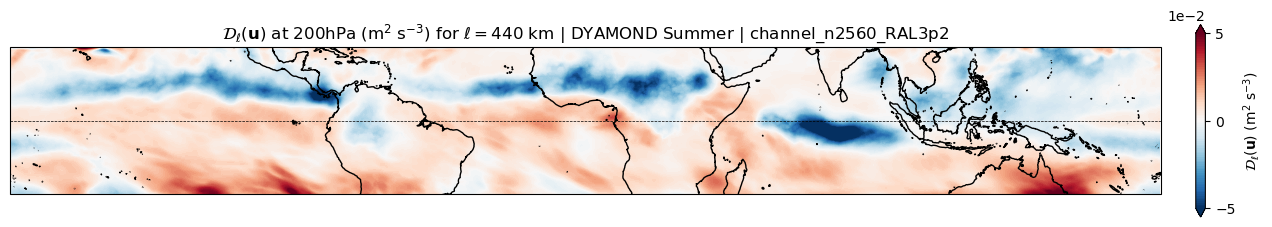

In [23]:
# As seen in Fig. 5b of McKinnon-Gray et al. (2026)
simid = 'channel_n2560_RAL3p2'
ell = 220000
lvl = 200

DR_map = DR_mean.sel(pressure=lvl,length_scale=ell,method='nearest')

# DR_map
plt.figure(figsize=(18,10))
ax = plt.axes(projection=ccrs.PlateCarree())
lon = DR_mean['longitude']
lat = DR_mean['latitude']

plt.contourf(lon,lat,DR_map.T,cmap='RdBu_r',levels=np.linspace(-5e-4,5e-4,100),extend='both')
ax.coastlines()
ax.set_extent([-180,180,-23,23])

plt.title(r'$\mathcal{D}_\ell(\mathbf{u})$ at'+f' {lvl}hPa ' + r'(m$^2$ s$^{-3}$) for $\ell = '+f'{int(ell*2/1000)}$ km | DYAMOND Summer | '+f'{simid}')
cbar=plt.colorbar(orientation='vertical', shrink=0.25, pad=0.025)
cbar.set_label(r'$\mathcal{D}_\ell(\mathbf{u}) \ $(m$^2$ s$^{-3}$)')
ax.axhline(y=0,color='k',linewidth=0.5,linestyle='--')
cbar.formatter = ticker.ScalarFormatter()
cbar.formatter.set_scientific(True)
cbar.formatter.set_powerlimits((-2, 3))
cbar.update_ticks() 
cbar.set_ticks([-0.05,0,0.05])

##### Longitudinally averaged vertical slice (as seen in Fig. 6b but without the winds)

In [24]:
DR_vertslice_2D_lat = DR_mean.sel(length_scale=ell,method='nearest').mean(dim='longitude')
DR_vertslice_2D_lat

<xarray.DataArray 'Dl_u' (latitude: 131, pressure: 12)> Size: 13kB
array([[ 2.50951289e-07,  1.53553092e-06,  8.51669291e-07, ...,
        -1.93485347e-06, -1.89931972e-06,  1.10231926e-06],
       [ 7.00045036e-07,  1.55343285e-05,  1.78163757e-05, ...,
        -4.97247303e-06, -1.96207967e-06,  7.06436471e-06],
       [ 2.40459972e-06,  2.75479939e-05,  4.08086213e-05, ...,
        -8.50101672e-06,  1.03850096e-06,  1.87045772e-05],
       ...,
       [-1.55865577e-06, -1.34870793e-05, -1.71117995e-05, ...,
         8.96508992e-06,  1.32226451e-05,  7.14642021e-06],
       [-3.48719116e-07, -6.95873740e-06, -1.25306497e-05, ...,
         2.58923795e-06,  4.98333329e-06,  3.67488126e-06],
       [-7.14554876e-08, -2.28735080e-06, -4.09130011e-06, ...,
         4.38917035e-07,  1.76620177e-06,  1.16778175e-06]],
      shape=(131, 12))
Coordinates:
    length_scale  float64 8B 2.2e+05
  * pressure      (pressure) float32 48B 100.0 150.0 200.0 ... 850.0 925.0 1e+03
  * latitude      (latitude) float64 1kB -39.5 -39.0 -38.5 ... 24.5 25.0 25.5

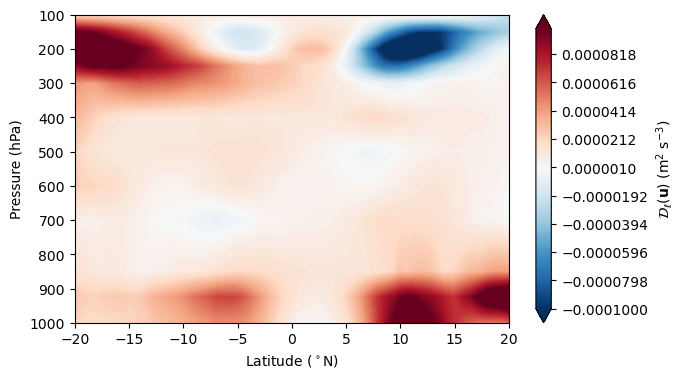

In [27]:
fig,ax = plt.subplots(figsize=(7,4))
CS = ax.contourf(DR_vertslice_2D_lat['latitude'],
             DR_vertslice_2D_lat['pressure'],
             DR_vertslice_2D_lat.T,
             cmap='RdBu_r',
             levels=np.linspace(-1e-4,1e-4,100),extend='both')
ax.invert_yaxis()

ax.set_ylabel('Pressure (hPa)')
ax.set_xlabel(r'Latitude ($^\circ$N)')
ax.set_xlim([-20,20])
fig.colorbar(CS, ax=ax, orientation='vertical', label=r'$\mathcal{D}_\ell(\mathbf{u})$ (m$^2$ s$^{-3}$)')

##### Banding of $\mathcal{D}_\ell$ to quantify energy *into* a band of scales. Logic is:

$\Delta\mathcal{D}_{\ell}(\ell_1,\ell_2) = \mathcal{D}_{\ell_1} - \mathcal{D}_{\ell_2}$ for $\ell_1 > \ell_2$

At the upper and lower bounds of $\ell$:

$\Delta\mathcal{D}_\ell(\ell_{min},0) = \mathcal{D}_{\ell_{min}} \ ;$

$\Delta\mathcal{D}_\ell(\infty,\ell_{max}) = -\mathcal{D}_{\ell_{max}}.$

In [45]:
ell_band_S = [55000]
ell_band_M = [110000, 440000]
ell_band_L = [440000, 1100000]
ell_band_XL = [1100000]

In [29]:
delta_DR_S = DR_mean.sel(length_scale=ell_band_S[0])
delta_DR_M = DR_mean.sel(length_scale=ell_band_M[-1]) - DR_mean.sel(length_scale=ell_band_M[0])
delta_DR_L = DR_mean.sel(length_scale=ell_band_L[-1]) - DR_mean.sel(length_scale=ell_band_L[0])
delta_DR_XL = -DR_mean.sel(length_scale=ell_band_XL[0])

##### Plotting: Banded $\mathcal{D}_\ell$ vs. $\ell$

Text(0.5, 0, 'Scale range (km)')

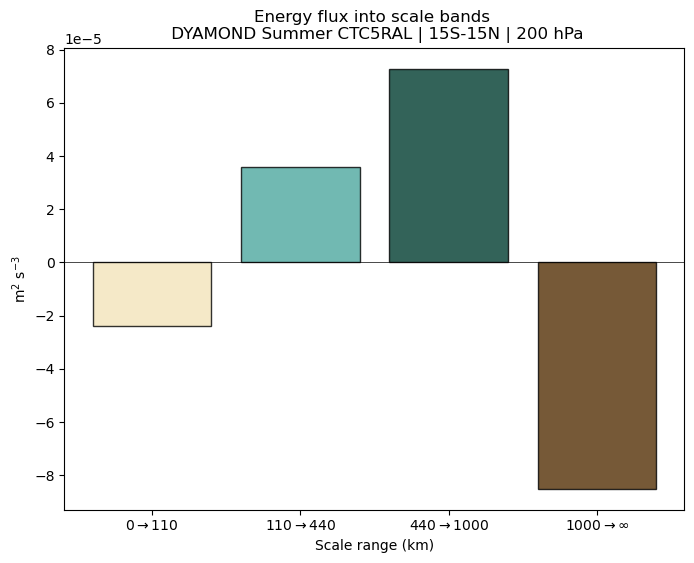

In [44]:
lvl = 200
vals = [delta_DR_S.sel(pressure=lvl,latitude=slice(-15,15)).mean(dim=['latitude','longitude']),\
        delta_DR_M.sel(pressure=lvl,latitude=slice(-15,15)).mean(dim=['latitude','longitude']),\
        delta_DR_L.sel(pressure=lvl,latitude=slice(-15,15)).mean(dim=['latitude','longitude']),\
        delta_DR_XL.sel(pressure=lvl,latitude=slice(-15,15)).mean(dim=['latitude','longitude'])]

sizes = [r'0$\to$110', r'110$\to$440', r'440$\to$1000', r'1000$\to\infty$']
norm = mcolors.Normalize(vmin=min(vals), vmax=max(vals))
cmap = plt.get_cmap("BrBG")
colors = [cmap(norm(val)) for val in vals]

# Plot the bar chart
fig, ax = plt.subplots(1, 1, figsize=(8, 6))  # Reduced figure size
ax.bar(sizes, vals, color=colors, alpha=0.8, edgecolor='k')
ax.axhline(0, linewidth=0.5, color='k')

# Add a colorbar
# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax)
# cbar.set_label(r'm$^2$ s$^{-3}$')

# Set title and labels
ax.set_title('Energy flux into scale bands \n DYAMOND Summer CTC5RAL | 15S-15N | 200 hPa')
ax.set_ylabel(r'm$^2$ s$^{-3}$')
ax.set_xlabel('Scale range (km)')